<h1 style="color:purple;">CNN con Smoothness Regularization + Lambda Schedule</h1>
<p> Valentina Arce España <p>
<p> Marzo 2026 <p>


<div class="alert alert-block alert-warning">
Versión 5: Se agrega un <b>Schedule de Regularización</b> sobre el parámetro λ de la Smoothness Loss.<br><br>
La función de pérdida sigue siendo:<br>
<code>L = MSE(h, y)  +  λ · (1/(m-1)) · dh<sup>T</sup> · dh</code><br><br>
La novedad es que <b>λ no es fijo</b>. En lugar de eso, sigue un schedule por épocas:<br>
<ul>
  <li><b>Fase libre</b> (épocas 1 → warmup_epochs): λ = 0. La red aprende la tendencia real del RUL sin restricciones.</li>
  <li><b>Fase de refinamiento</b> (épocas warmup → total): λ crece de 0 a λ_max siguiendo una curva sigmoidea.</li>
</ul>
Esto evita el colapso hacia predicciones constantes porque la red ya tiene una buena inicialización
antes de que la penalización de suavidad empiece a actuar.<br><br>
<b>Clave técnica:</b> λ es un <code>tf.Variable</code> (no un escalar Python) para que el callback
pueda modificarlo en tiempo real sin recompilar el modelo.
</div>


In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

# ==========================================
# 1. CONFIGURACION
# ==========================================
filename     = '/Users/mac/Documents/Programs/data/N-CMAPSS_DS08a-009.h5'
WINDOW_SIZE  = 50
BATCH_SIZE   = 512
EPOCHS       = 15
TRAIN_RATIO  = 0.8
WINDOW_STEP  = 10

print('Configuracion cargada.')

Configuracion cargada.


In [4]:
# ==========================================
# 2. CARGA DE DATOS
# ==========================================
def load_data(filepath):
    with h5py.File(filepath, 'r') as hdf:
        W_dev     = np.array(hdf.get('W_dev'))
        X_s_dev   = np.array(hdf.get('X_s_dev'))
        X_v_dev   = np.array(hdf.get('X_v_dev'))
        Y_dev     = np.array(hdf.get('Y_dev'))
        A_dev     = np.array(hdf.get('A_dev'))

        W_test    = np.array(hdf.get('W_test'))
        X_s_test  = np.array(hdf.get('X_s_test'))
        X_v_test  = np.array(hdf.get('X_v_test'))
        Y_test    = np.array(hdf.get('Y_test'))
        A_test    = np.array(hdf.get('A_test'))

        A_var_raw = np.array(hdf.get('A_var'))
        A_var     = list(np.array(A_var_raw, dtype='U20'))

    return (W_dev, X_s_dev, X_v_dev, Y_dev, A_dev), \
           (W_test, X_s_test, X_v_test, Y_test, A_test), A_var

print('Cargando datos...')
(train_W, train_Xs, train_Xv, train_Y, train_A), \
(test_W,  test_Xs,  test_Xv,  test_Y,  test_A), A_var = load_data(filename)

print(f'A_var (columnas de A): {A_var}')
print('Datos cargados correctamente.')

Cargando datos...


A_var (columnas de A): ['unit', 'cycle', 'Fc', 'hs']
Datos cargados correctamente.


In [5]:
# ==========================================
# 3. REDUCCION DE MOTORES (TRAIN)
# ==========================================
train_units      = np.unique(train_A[:, 0])
n_units_original = len(train_units)
n_units_keep     = int(n_units_original * TRAIN_RATIO) 
keep_units       = train_units[:n_units_keep]

print(f'Reduciendo dataset: usando {n_units_keep} de {n_units_original} motores.')

mask_train = np.isin(train_A[:, 0], keep_units)
train_W  = train_W[mask_train]
train_Xs = train_Xs[mask_train]
train_Xv = train_Xv[mask_train]
train_Y  = train_Y[mask_train]
train_A  = train_A[mask_train]

print(f'Motores en entrenamiento: {np.unique(train_A[:, 0])}')

Reduciendo dataset: usando 7 de 9 motores.
Motores en entrenamiento: [1. 2. 3. 4. 5. 6. 7.]


In [6]:
# ==========================================
# 4. PREPROCESAMIENTO Y ESCALADO
# ==========================================
X_train = np.concatenate((train_W, train_Xs, train_Xv), axis=1)
X_test  = np.concatenate((test_W,  test_Xs,  test_Xv),  axis=1)

scaler         = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Forma X_train (reducido): {X_train_scaled.shape}')
print(f'Forma X_test:             {X_test_scaled.shape}')

Forma X_train (reducido): (3911368, 32)
Forma X_test:             (3722997, 32)


In [7]:
# ==========================================
# 5. GENERACION DE VENTANAS
# ==========================================
# IMPORTANTE: cycle_col_index=1 asume A_var[1] = 'cycle'.
# Ajusta si el print de A_var muestra un orden distinto.

def create_windows_with_meta(X, y, A, window_size, step=1,
                             unit_col_index=0, cycle_col_index=1):
    unique_units = np.unique(A[:, unit_col_index])
    X_windows, y_windows, meta = [], [], []

    for unit in unique_units:
        idx    = np.where(A[:, unit_col_index] == unit)[0]
        unit_X = X[idx, :]
        unit_y = y[idx]
        unit_A = A[idx]

        n = len(unit_X)
        if n < window_size:
            continue

        for i in range(0, n - window_size + 1, step):
            X_windows.append(unit_X[i : i + window_size, :])
            y_windows.append(unit_y[i + window_size - 1])
            meta.append((unit, unit_A[i + window_size - 1, cycle_col_index]))

    return np.array(X_windows), np.array(y_windows), np.array(meta)


print(f'Generando ventanas de entrenamiento (Step={WINDOW_STEP})...')
X_train_w, y_train_w, train_meta = create_windows_with_meta(
    X_train_scaled, train_Y, train_A, WINDOW_SIZE, step=WINDOW_STEP
)

print('Generando ventanas de test (Step=10)...')
X_test_w, y_test_w, test_meta = create_windows_with_meta(
    X_test_scaled, test_Y, test_A, WINDOW_SIZE, step=10
)

# Ordenar train por (unit, ciclo) --- CRITICO para que dh sea valido
sort_idx   = np.lexsort((train_meta[:, 1], train_meta[:, 0]))
X_train_w  = X_train_w[sort_idx]
y_train_w  = y_train_w[sort_idx]
train_meta = train_meta[sort_idx]

print(f'Input Shape Train: {X_train_w.shape}')
print(f'Input Shape Test:  {X_test_w.shape}')
print(f'Primeras 5 ventanas (unit, ciclo_fin): {train_meta[:5]}')
print(f'Ultimas  5 ventanas (unit, ciclo_fin): {train_meta[-5:]}')

Generando ventanas de entrenamiento (Step=10)...
Generando ventanas de test (Step=10)...
Input Shape Train: (391104, 50, 32)
Input Shape Test:  (372274, 50, 32)
Primeras 5 ventanas (unit, ciclo_fin): [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Ultimas  5 ventanas (unit, ciclo_fin): [[ 7. 68.]
 [ 7. 68.]
 [ 7. 68.]
 [ 7. 68.]
 [ 7. 68.]]


In [8]:
# ==========================================
# 6. ARQUITECTURA CNN
# ==========================================
input_shape = (X_train_w.shape[1], X_train_w.shape[2])

model = models.Sequential([
    layers.Conv1D(64,  3, activation='relu', input_shape=input_shape, padding='same'),
    layers.Conv1D(64,  3, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 5, activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/opt/miniconda3/envs/tesis_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 25, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,697 (1.82 MB)

 Trainable params: 477,697 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ==========================================
# 7. ENTRENAMIENTO FASE 1 --- MSE PURO
# ==========================================
print('Iniciando entrenamiento con MSE puro...')
history_mse = model.fit(
    X_train_w, y_train_w,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
print('Entrenamiento MSE finalizado.')

Iniciando entrenamiento con MSE puro...
Epoch 1/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 129s 183ms/step - loss: 131.5773 - val_loss: 20.3247
Epoch 2/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 91s 132ms/step - loss: 46.8427 - val_loss: 19.5447
Epoch 3/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 113s 164ms/step - loss: 43.6136 - val_loss: 33.3139
Epoch 4/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 90s 131ms/step - loss: 39.0146 - val_loss: 14.7183
Epoch 5/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 90s 131ms/step - loss: 38.3237 - val_loss: 16.1399
Epoch 6/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 106s 153ms/step - loss: 36.1689 - val_loss: 20.7470
Epoch 7/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 95s 138ms/step - loss: 34.8158 - val_loss: 14.3313
Epoch 8/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 89s 130ms/step - loss: 34.6190 - val_loss: 24.2185
Epoch 9/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 89s 130ms/step - loss: 33.8060 - val_loss: 30.3108
Epoch 10/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 92s 134ms/step - loss: 31.4858 - val_loss: 19.2415
Epoch 11/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 93s 

Prediciendo con modelo MSE...
RMSE baseline (MSE puro): 7.3461
Bias baseline (MSE puro): -2.9487


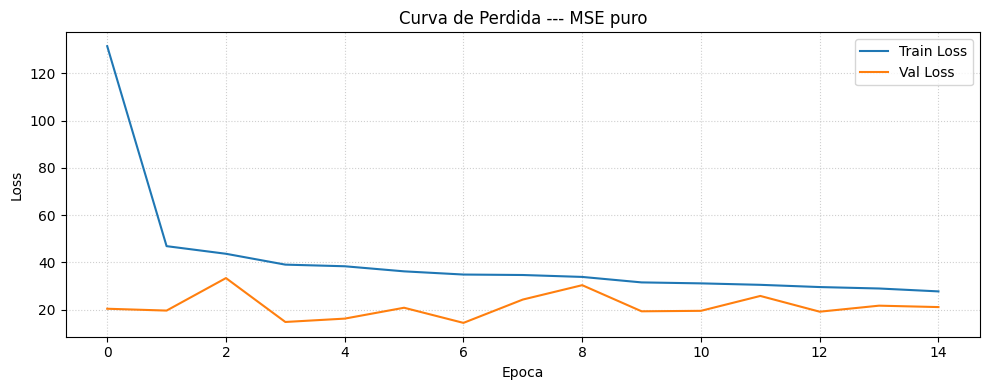

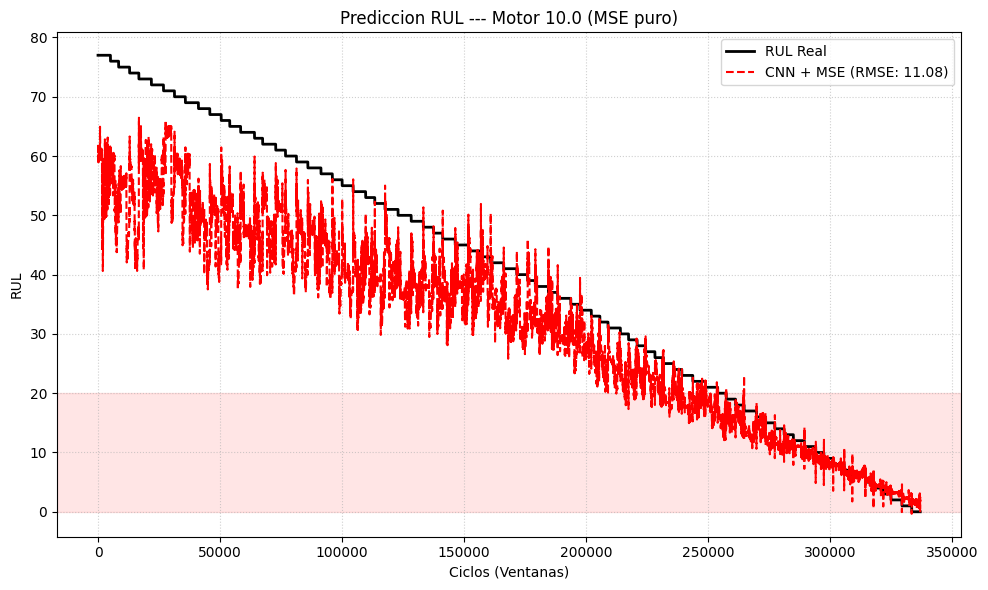

In [10]:
# ==========================================
# 8. EVALUACION BASELINE --- MODELO MSE
# ==========================================
print('Prediciendo con modelo MSE...')
y_pred_mse = model.predict(X_test_w, verbose=0).flatten()  # flatten para evitar broadcast
rmse_base  = np.sqrt(mean_squared_error(y_test_w, y_pred_mse))
bias_base  = np.mean(y_test_w.flatten() - y_pred_mse)

print(f'RMSE baseline (MSE puro): {rmse_base:.4f}')
print(f'Bias baseline (MSE puro): {bias_base:.4f}')

# Curva de perdida
plt.figure(figsize=(10, 4))
plt.plot(history_mse.history['loss'],     label='Train Loss')
plt.plot(history_mse.history['val_loss'], label='Val Loss')
plt.title('Curva de Perdida --- MSE puro')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Grafica primer motor de test
target_unit  = np.unique(test_A[:, 0])[0]
idx_unit     = np.where(test_A[:, 0] == target_unit)[0]
X_u, y_u, _ = create_windows_with_meta(
    X_test_scaled[idx_unit], test_Y[idx_unit], test_A[idx_unit], WINDOW_SIZE, step=1
)
y_u_pred_mse = model.predict(X_u, verbose=0).flatten()
y_u_flat     = y_u.flatten()

plt.figure(figsize=(10, 6))
plt.plot(y_u_flat, label='RUL Real', color='black', linewidth=2)
plt.plot(y_u_pred_mse, label=f'CNN + MSE (RMSE: {np.sqrt(mean_squared_error(y_u_flat, y_u_pred_mse)):.2f})',
         color='red', linestyle='--', linewidth=1.5)
plt.axhspan(0, 20, color='red', alpha=0.1)
plt.title(f'Prediccion RUL --- Motor {target_unit} (MSE puro)')
plt.xlabel('Ciclos (Ventanas)')
plt.ylabel('RUL')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# 9. GUARDAR MODELO MSE
# ==========================================
model.save('modelo_mse_v4_schedule.keras')
print("Modelo MSE guardado como 'modelo_mse_v4_schedule.keras'")

Modelo MSE guardado como 'modelo_mse_v4_schedule.keras'


In [12]:
# ==========================================
# 10. VARIABLE LAMBDA Y FUNCIÓN DE PÉRDIDA
# ==========================================
#
# CLAVE: lambda_var es un tf.Variable, NO un escalar Python.
# Esto permite que el callback lo modifique epoch-a-epoch
# sin necesidad de recompilar el modelo.
#
# Schedule sigmoidea:
#   - Épocas [0, WARMUP_EPOCHS)     -> lambda = 0   (fase libre)
#   - Épocas [WARMUP_EPOCHS, TOTAL) -> lambda sube de 0 a LAMBDA_MAX
#     usando una sigmoidea para una transición suave

LAMBDA_MAX    = 0.01   # Techo de la penalización. Ajustar si la curva
                       # sigue ruidosa (subir) o si el RMSE sube mucho (bajar).
WARMUP_EPOCHS = 5      # Épocas de fase libre (MSE puro). Mínimo recomendado: 3.
TOTAL_EPOCHS  = 20     # Épocas totales del fine-tuning con schedule.
STEEPNESS     = 0.5    # Qué tan rápido sube la sigmoidea. Valores típicos: 0.3 - 1.0.
#                        Mayor = sube más rápido hacia LAMBDA_MAX.

# tf.Variable mutable — el callback puede asignarlo directamente
lambda_var = tf.Variable(0.0, trainable=False, dtype=tf.float32, name="lambda_smooth")

def mse_smoothness_loss(y_true, y_pred):
    """MSE + lambda_var * (1/(m-1)) * sum(dh^2)"""
    mse_term        = K.mean(K.square(y_true - y_pred))
    dh              = y_pred[1:] - y_pred[:-1]
    smoothness_term = K.mean(K.square(dh))
    return mse_term + lambda_var * smoothness_term


class LambdaScheduleCallback(tf.keras.callbacks.Callback):
    """
    Actualiza lambda_var al inicio de cada época según:

       epoch < warmup_epochs  →  λ = 0
       epoch >= warmup_epochs →  λ = λ_max * sigmoid(steepness * (epoch - midpoint))

    donde midpoint es el punto medio de la fase de refinamiento.
    """
    def __init__(self, lambda_variable, lambda_max, warmup_epochs,
                 total_epochs, steepness=0.5):
        super().__init__()
        self.lv            = lambda_variable
        self.lambda_max    = lambda_max
        self.warmup        = warmup_epochs
        self.total         = total_epochs
        self.steepness     = steepness
        self.history_lam   = []   # para graficar después

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup:
            new_lam = 0.0
        else:
            # midpoint = época central de la fase de refinamiento
            midpoint = self.warmup + (self.total - self.warmup) / 2.0
            x        = self.steepness * (epoch - midpoint)
            sigmoid  = 1.0 / (1.0 + np.exp(-x))
            new_lam  = float(self.lambda_max * sigmoid)

        self.lv.assign(new_lam)
        self.history_lam.append(new_lam)
        if epoch % 5 == 0 or epoch < self.warmup + 2:
            print(f"  [LambdaSchedule] Época {epoch+1:02d} → λ = {new_lam:.6f}")


# Instanciar el callback
lambda_callback = LambdaScheduleCallback(
    lambda_variable = lambda_var,
    lambda_max      = LAMBDA_MAX,
    warmup_epochs   = WARMUP_EPOCHS,
    total_epochs    = TOTAL_EPOCHS,
    steepness       = STEEPNESS
)

print(f"Loss con schedule definida.")
print(f"  LAMBDA_MAX    = {LAMBDA_MAX}")
print(f"  WARMUP_EPOCHS = {WARMUP_EPOCHS}")
print(f"  TOTAL_EPOCHS  = {TOTAL_EPOCHS}")
print(f"  STEEPNESS     = {STEEPNESS}")


Loss con schedule definida.
  LAMBDA_MAX    = 0.01
  WARMUP_EPOCHS = 5
  TOTAL_EPOCHS  = 20
  STEEPNESS     = 0.5


In [ ]:
# ==========================================
# 11. FINE-TUNING CON LAMBDA SCHEDULE
# ==========================================
model_smooth = load_model('modelo_mse_v4_schedule.keras')

model_smooth.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=mse_smoothness_loss
)
print('Modelo cargado y compilado con MSE + Smoothness Schedule.')

# CRITICO: shuffle=False para que dh corresponda a ciclos consecutivos
print('Iniciando Fine-Tuning con Lambda Schedule...')
history_smooth = model_smooth.fit(
    X_train_w, y_train_w,
    epochs          = TOTAL_EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_split= 0.1,
    shuffle         = False,          # CRITICO: mantiene orden (unit, ciclo)
    callbacks       = [lambda_callback],
    verbose         = 1
)
print('Fine-Tuning con Schedule finalizado!')


Modelo cargado y compilado con MSE + Smoothness Schedule.
Iniciando Fine-Tuning con Lambda Schedule...
  [LambdaSchedule] Época 01 → λ = 0.000000
Epoch 1/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 95s 134ms/step - loss: 48.8477 - val_loss: 12.1063
  [LambdaSchedule] Época 02 → λ = 0.000000
Epoch 2/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 90s 130ms/step - loss: 98.0433 - val_loss: 45.0991
  [LambdaSchedule] Época 03 → λ = 0.000000
Epoch 3/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 89s 129ms/step - loss: 129.1800 - val_loss: 55.9983
  [LambdaSchedule] Época 04 → λ = 0.000000
Epoch 4/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 96s 139ms/step - loss: 137.7374 - val_loss: 155.7468
  [LambdaSchedule] Época 05 → λ = 0.000000
Epoch 5/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 89s 129ms/step - loss: 148.4992 - val_loss: 271.3423
  [LambdaSchedule] Época 06 → λ = 0.000230
Epoch 6/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 88s 128ms/step - loss: 186.2205 - val_loss: 205.5286
  [LambdaSchedule] Época 07 → λ = 0.000373
Epoch 7/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 96s

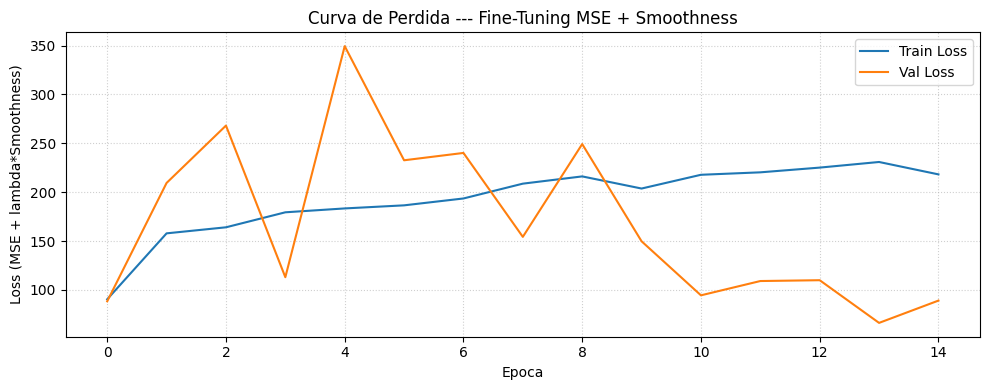

In [27]:
# ==========================================
# 12. CURVAS DE PÉRDIDA Y LAMBDA SCHEDULE
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# — Curva de pérdida —
axes[0].plot(history_smooth.history['loss'],     label='Train Loss', color='royalblue')
axes[0].plot(history_smooth.history['val_loss'], label='Val Loss',   color='orange', linestyle='--')
axes[0].axvline(WARMUP_EPOCHS - 1, color='gray', linestyle=':', linewidth=1.5,
                label=f'Fin warmup (época {WARMUP_EPOCHS})')
axes[0].set_title('Curva de Pérdida — Fine-Tuning con Schedule', fontsize=13)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (MSE + λ·Smoothness)')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# — Lambda schedule —
axes[1].plot(range(1, len(lambda_callback.history_lam) + 1),
             lambda_callback.history_lam,
             color='darkgreen', linewidth=2, marker='o', markersize=4)
axes[1].axvline(WARMUP_EPOCHS, color='gray', linestyle=':', linewidth=1.5,
                label=f'Fin warmup (época {WARMUP_EPOCHS})')
axes[1].set_title('Evolución de λ por Época (Schedule Sigmoidea)', fontsize=13)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('λ (lambda_var)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"λ final usado en entrenamiento: {lambda_callback.history_lam[-1]:.6f}")


In [ ]:
# ==========================================
# 12b. DIAGNÓSTICO RÁPIDO DEL SCHEDULE
# ==========================================
# Muestra cómo habría evolucionado λ con distintos valores de STEEPNESS.
# Útil para decidir si la curva sube muy rápido o muy despacio.

epochs_range = np.arange(TOTAL_EPOCHS)
midpoint     = WARMUP_EPOCHS + (TOTAL_EPOCHS - WARMUP_EPOCHS) / 2.0

plt.figure(figsize=(10, 4))
for steep in [0.2, 0.5, 1.0, 2.0]:
    lams = []
    for e in epochs_range:
        if e < WARMUP_EPOCHS:
            lams.append(0.0)
        else:
            x = steep * (e - midpoint)
            lams.append(LAMBDA_MAX / (1.0 + np.exp(-x)))
    style = '-' if steep == STEEPNESS else '--'
    lw    = 2.5 if steep == STEEPNESS else 1.2
    plt.plot(epochs_range + 1, lams,
             label=f'steepness={steep}' + (' ← ACTUAL' if steep == STEEPNESS else ''),
             linewidth=lw, linestyle=style)

plt.axvline(WARMUP_EPOCHS, color='gray', linestyle=':', linewidth=1.5,
            label=f'Fin warmup (época {WARMUP_EPOCHS})')
plt.title('Comparativa de Schedules por Steepness', fontsize=13)
plt.xlabel('Época')
plt.ylabel('λ')
plt.legend(fontsize=9)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


In [28]:
# ==========================================
# 13. COMPARATIVA GLOBAL --- MSE vs MSE+SMOOTHNESS
# ==========================================
y_pred_mse    = model.predict(X_test_w,       verbose=0).flatten()
y_pred_smooth = model_smooth.predict(X_test_w, verbose=0).flatten()
y_test_flat   = y_test_w.flatten()

rmse_mse    = np.sqrt(mean_squared_error(y_test_flat, y_pred_mse))
rmse_smooth = np.sqrt(mean_squared_error(y_test_flat, y_pred_smooth))
bias_mse    = np.mean(y_test_flat - y_pred_mse)
bias_smooth = np.mean(y_test_flat - y_pred_smooth)
std_mse     = np.std(np.diff(y_pred_mse))
std_smooth  = np.std(np.diff(y_pred_smooth))

print('============================================')
print('        COMPARATIVA GLOBAL EN TEST          ')
print('============================================')
print(f'{"Modelo":<22} {"RMSE":>8} {"Bias":>8} {"Std(dh)":>10}')
print('-' * 50)
print(f'{"MSE puro":<22} {rmse_mse:>8.4f} {bias_mse:>8.4f} {std_mse:>10.4f}')
print(f'{"MSE + Smoothness":<22} {rmse_smooth:>8.4f} {bias_smooth:>8.4f} {std_smooth:>10.4f}')
print('============================================')
print('Std(dh): menor valor = curvas de RUL mas suaves.')

        COMPARATIVA GLOBAL EN TEST          
Modelo                     RMSE     Bias    Std(dh)
--------------------------------------------------
MSE puro                 7.5571  -3.5035     0.4979
MSE + Smoothness        13.7651  -2.8039     0.4404
Std(dh): menor valor = curvas de RUL mas suaves.


Generando comparativa para el Motor 10.0...


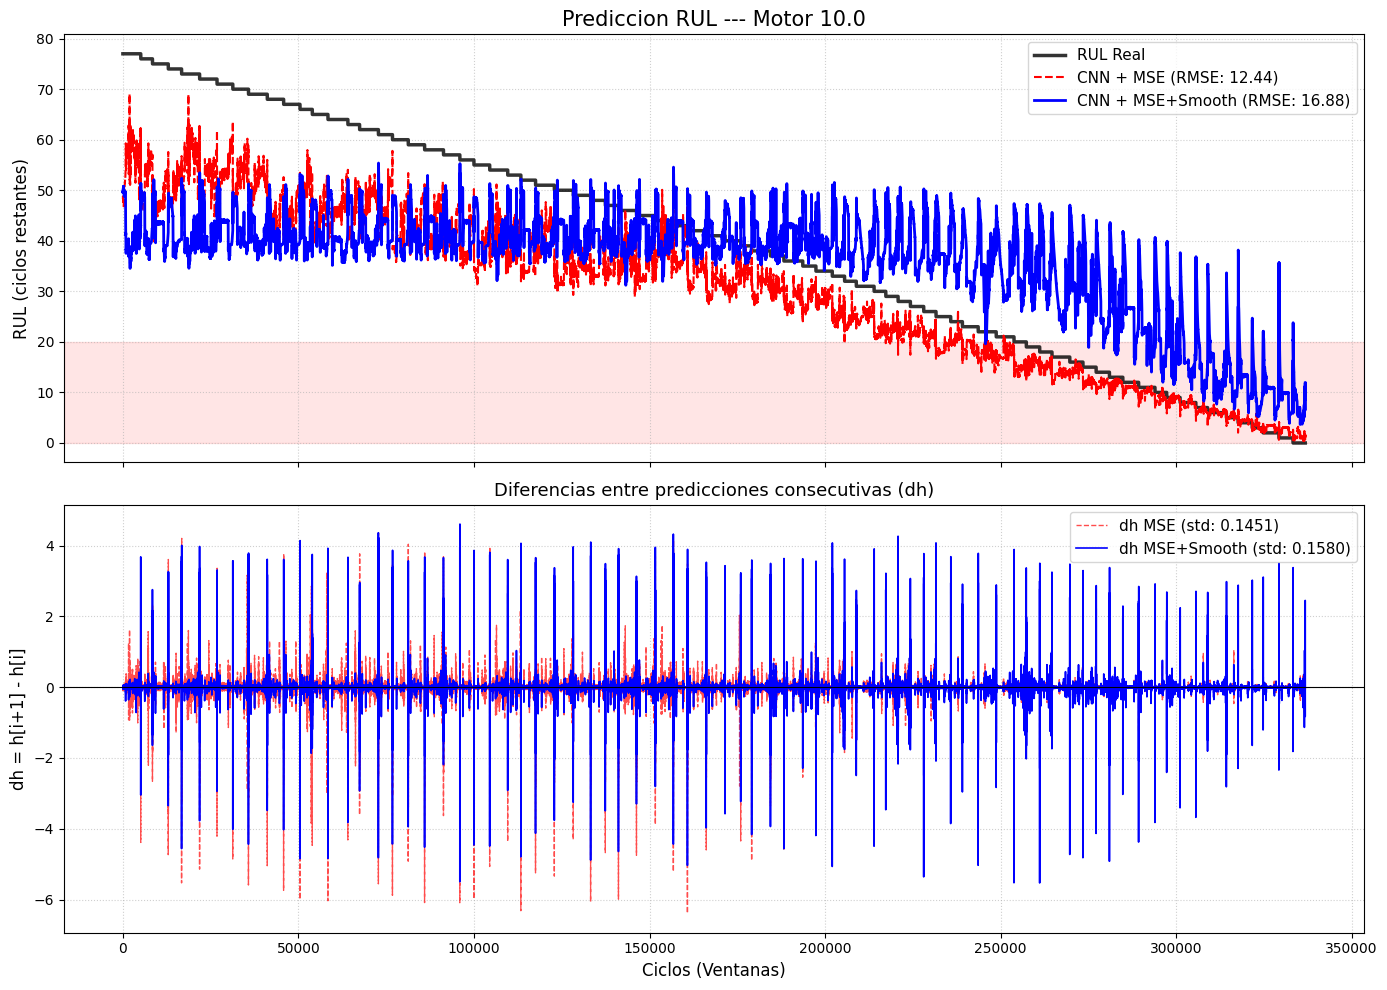

In [29]:
# ==========================================
# 14. COMPARATIVA POR MOTOR
# ==========================================
def comparar_motores(unit_id):
    idx = np.where(test_A[:, 0] == unit_id)[0]
    if len(idx) == 0:
        print(f'Motor {unit_id} no encontrado en el set de test.')
        return

    print(f'Generando comparativa para el Motor {unit_id}...')
    X_u, y_u, _ = create_windows_with_meta(
        X_test_scaled[idx], test_Y[idx], test_A[idx], WINDOW_SIZE, step=1
    )

    pred_mse_u    = model.predict(X_u,        verbose=0).flatten()
    pred_smooth_u = model_smooth.predict(X_u,  verbose=0).flatten()

    rmse_mse_u    = np.sqrt(mean_squared_error(y_u, pred_mse_u))
    rmse_smooth_u = np.sqrt(mean_squared_error(y_u, pred_smooth_u))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    ax1.plot(y_u, label='RUL Real', color='black', linewidth=2.5, alpha=0.8)
    ax1.plot(pred_mse_u,    label=f'CNN + MSE (RMSE: {rmse_mse_u:.2f})',
             color='red',  linestyle='--', linewidth=1.5)
    ax1.plot(pred_smooth_u, label=f'CNN + MSE+Smooth (RMSE: {rmse_smooth_u:.2f})',
             color='blue', linewidth=2)
    ax1.axhspan(0, 20, color='red', alpha=0.1)
    ax1.set_title(f'Prediccion RUL --- Motor {unit_id}', fontsize=15)
    ax1.set_ylabel('RUL (ciclos restantes)', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, linestyle=':', alpha=0.6)

    dh_mse    = np.diff(pred_mse_u)
    dh_smooth = np.diff(pred_smooth_u)
    ax2.plot(dh_mse,    label=f'dh MSE (std: {np.std(dh_mse):.4f})',
             color='red',  linestyle='--', linewidth=1, alpha=0.7)
    ax2.plot(dh_smooth, label=f'dh MSE+Smooth (std: {np.std(dh_smooth):.4f})',
             color='blue', linewidth=1.2)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_title('Diferencias entre predicciones consecutivas (dh)', fontsize=13)
    ax2.set_xlabel('Ciclos (Ventanas)', fontsize=12)
    ax2.set_ylabel('dh = h[i+1] - h[i]', fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()


target_unit = np.unique(test_A[:, 0])[0]
comparar_motores(target_unit)

# Descomenta para ver otros motores:
# comparar_motores(np.unique(test_A[:, 0])[1])
# comparar_motores(np.unique(test_A[:, 0])[2])

Generando comparativa para el Motor 13.0...


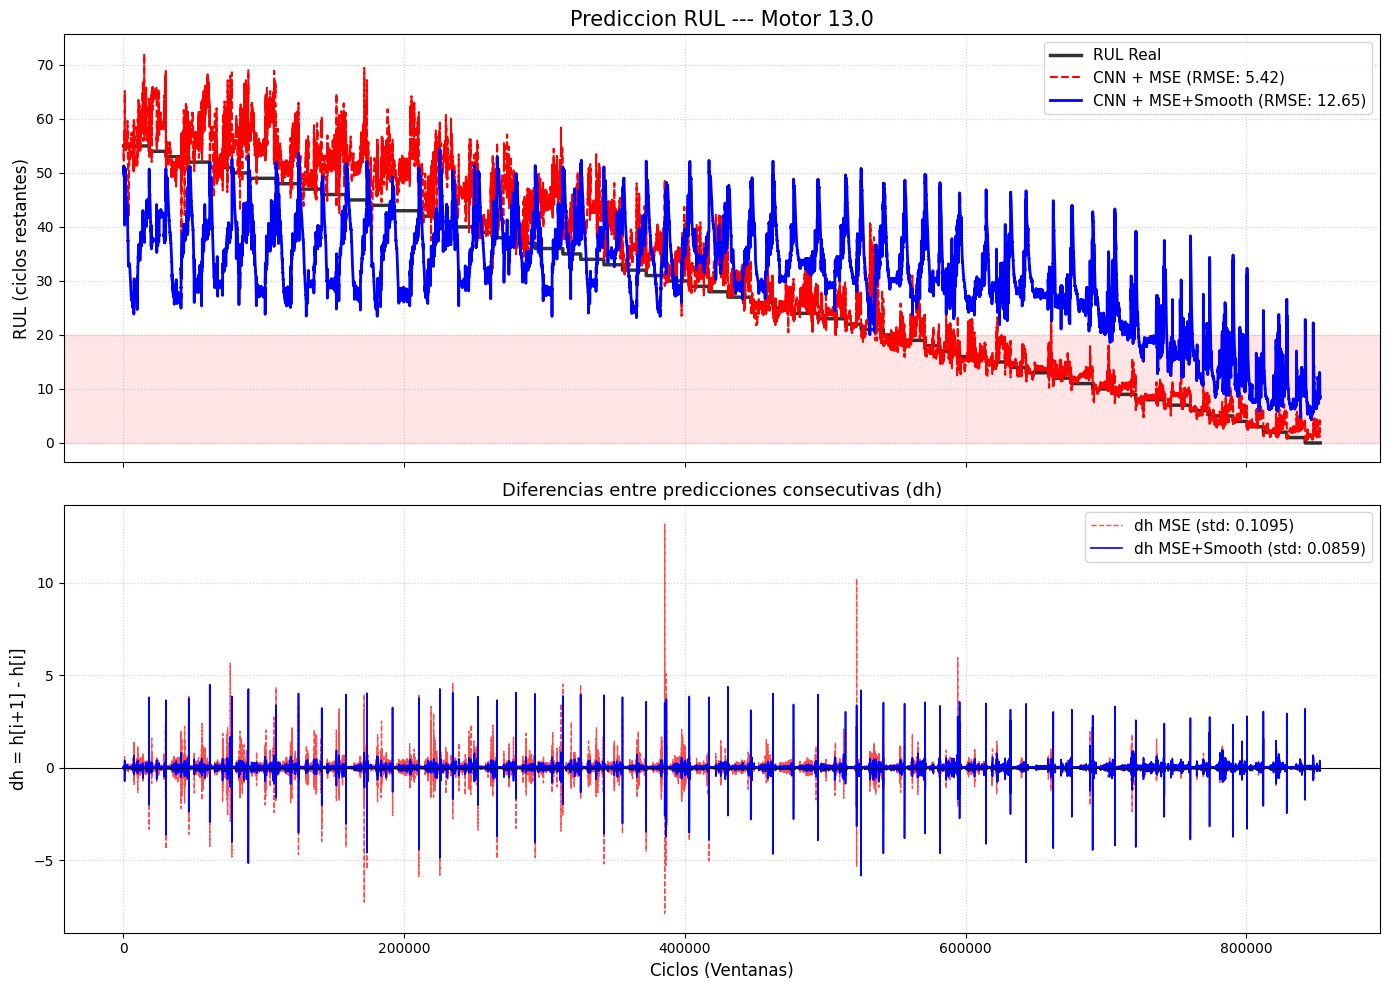

In [30]:
# ==========================================
# 16. PREDICCION PARA MOTOR 13
# ==========================================
comparar_motores(13.0)

In [17]:
# ==========================================
# 15. GUARDAR MODELO FINAL
# ==========================================
model_smooth.save('modelo_mse_smoothness_v4_MoreTrain.keras')
print("Modelo MSE + Smoothness guardado como 'modelo_mse_smoothness_v4.keras'")

Modelo MSE + Smoothness guardado como 'modelo_mse_smoothness_v4.keras'
